# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [1]:
!pip install shap -qU


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install -qU pyALE


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
!pip install -qU lime fat-forensics[all]


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error

In [5]:
!wget  -O 'world-happiness-report-2021-prep.csv' -q 'https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=0'

In [6]:
data_to_work = pd.read_csv('world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [7]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [8]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [9]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [10]:
reg_lin_minmax = LinearRegression()
reg_lin_minmax.fit(X_train_sc_minmax, y_train)
lin_minmax_mse_train = mean_squared_error(y_train, reg_lin_minmax.predict(X_train_sc_minmax))
lin_minmax_mse_test = mean_squared_error(y_test, reg_lin_minmax.predict(X_test_sc_minmax))
print(lin_minmax_mse_train, lin_minmax_mse_train**0.5)
print(lin_minmax_mse_test, lin_minmax_mse_test**0.5)

7.052091613303664e-07 0.0008397673257101436
9.841902235101229e-07 0.00099206361868084


In [11]:
reg_lin_standard = LinearRegression()
reg_lin_standard.fit(X_train_sc_standard, y_train)
lin_standard_mse_train = mean_squared_error(y_train, reg_lin_standard.predict(X_train_sc_standard))
lin_standard_mse_test = mean_squared_error(y_test, reg_lin_standard.predict(X_test_sc_standard))
print(lin_standard_mse_train, lin_standard_mse_train**0.5)
print(lin_standard_mse_test, lin_standard_mse_test**0.5)

7.052091613302464e-07 0.0008397673257100721
9.84190223510141e-07 0.000992063618680849


In [12]:
reg_lasso_minmax = Lasso(alpha=0.1,random_state=42)
reg_lasso_minmax.fit(X_train_sc_minmax, y_train)
lasso_minmax_mse_train = mean_squared_error(y_train, reg_lasso_minmax.predict(X_train_sc_minmax))
lasso_minmax_mse_test = mean_squared_error(y_test, reg_lasso_minmax.predict(X_test_sc_minmax))
print(lasso_minmax_mse_train, lasso_minmax_mse_train**0.5)
print(lasso_minmax_mse_test, lasso_minmax_mse_test**0.5)

0.5443132232130731 0.7377758624494793
0.4887543770405633 0.6991097031514891


In [13]:
reg_lasso_standard = Lasso(alpha=0.1,random_state=42)
reg_lasso_standard.fit(X_train_sc_standard, y_train)
lasso_standard_mse_train = mean_squared_error(y_train, reg_lasso_standard.predict(X_train_sc_standard))
lasso_standard_mse_test = mean_squared_error(y_test, reg_lasso_standard.predict(X_test_sc_standard))
print(lasso_standard_mse_train, lasso_standard_mse_train**0.5)
print(lasso_standard_mse_test, lasso_standard_mse_test**0.5)

0.03447637182485858 0.18567814040661487
0.02981211894866825 0.1726618630406502


In [14]:
reg_grad_minmax = GradientBoostingRegressor(max_depth=2, random_state=42) # max_depth=5 очень сильно переобучалась, так как формулировка ограничьте глубину ДО 5 решил сделать max_depth=2, так достигается наилучший баланс
reg_grad_minmax.fit(X_train_sc_minmax, y_train)
grad_minmax_mse_train = mean_squared_error(y_train, reg_grad_minmax.predict(X_train_sc_minmax))
grad_minmax_mse_test = mean_squared_error(y_test, reg_grad_minmax.predict(X_test_sc_minmax))
print(grad_minmax_mse_train, grad_minmax_mse_train**0.5)
print(grad_minmax_mse_test, grad_minmax_mse_test**0.5)

0.0036738300596216604 0.06061212799120041
0.04366991595637728 0.2089734814668533


In [15]:
reg_grad_standard = GradientBoostingRegressor(max_depth=2,random_state=42)
reg_grad_standard.fit(X_train_sc_standard, y_train)
grad_standard_mse_train = mean_squared_error(y_train, reg_grad_standard.predict(X_train_sc_standard))
grad_standard_mse_test = mean_squared_error(y_test, reg_grad_standard.predict(X_test_sc_standard))
print(grad_standard_mse_train, grad_standard_mse_train**0.5)
print(grad_standard_mse_test, grad_standard_mse_test**0.5)

0.0036738300596216604 0.06061212799120041
0.043766212393710854 0.20920375807740849


Выводы
1. Линейная регрессия обучилась практически идеально, между MinMaxScaler и StandardScaler разница минимальна, но немного выигрывает Standard. В целом это ожидаемо, так как масштаб признаков влияет только на веса, которые подстраиваются
2. Для Lasso метод масштабирования сильно повлиял. Standard показал качество лучше так как при нем признаки сопоставимы по разбросу, следовательно регуляризация работает адекватнее. alpha=0.1 я подобрал вручную потому что при alpha=1 результаты были одинаковыми и не показательными
3. Дерево переобучилось, max_depth=2 по качеству оказался оптимальным, но результаты практически не зависят от метода масштабирования, так как в целом дереву без разницы какой у признака порядок, модель перебирает все комбинации порогов и фич и выбирает наилучший

## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

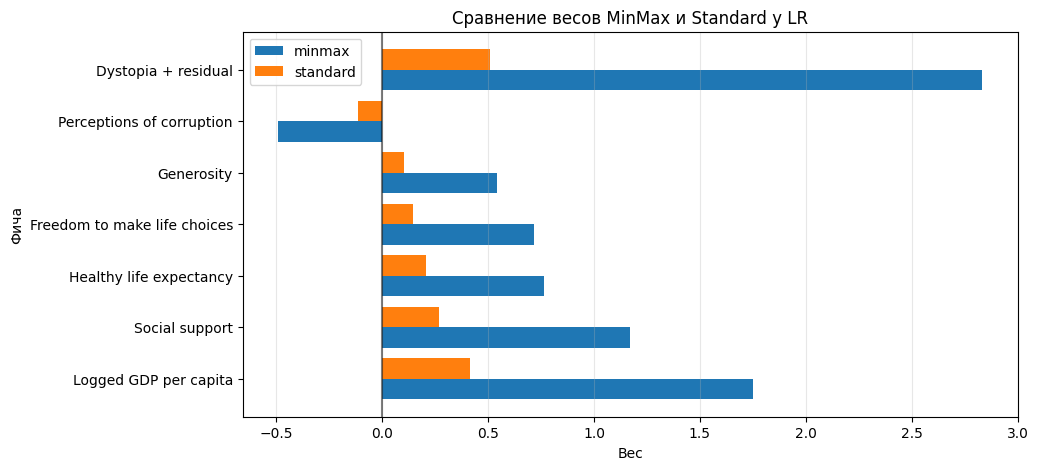

In [16]:
feature_positions = np.arange(reg_lin_minmax.n_features_in_)

reg_lin_minmax_coefs = reg_lin_minmax.coef_
reg_lin_standard_coefs = reg_lin_standard.coef_

fig, ax = plt.subplots(figsize=(10,5))

ax.barh(y=feature_positions-0.2, width=reg_lin_minmax_coefs, height=0.4, label="minmax")
ax.barh(y=feature_positions+0.2, width=reg_lin_standard_coefs, height=0.4, label="standard")

ax.set_yticks(feature_positions)
ax.set_yticklabels(feature_names)
ax.grid(axis="x", alpha=0.3)
ax.axvline(x=0, color="black", alpha=0.5)
ax.set_title("Сравнение весов MinMax и Standard у LR")
ax.set_ylabel("Фича")
ax.set_xlabel("Вес")
ax.legend()

plt.show()

**Ваш вывод здесь:** Так как у standard признаки приводятся к сопоставимому разбросу веса становятся более равномерными. Поэтому мы видим, что в среднем коэффициенты где то в 5 раз больше у MinMax. В общем то в больших весах пользы нет, так что в случае линейной регрессии Standard выглядит предпочтительнее

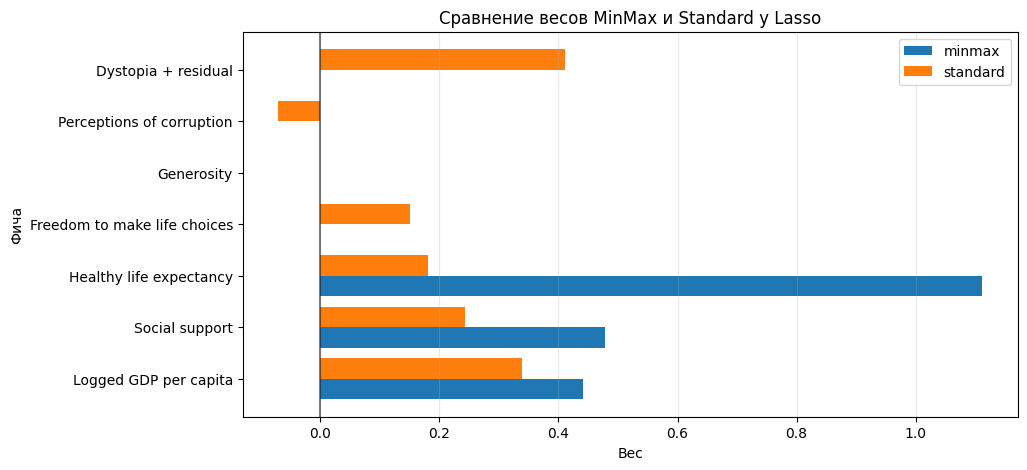

In [17]:
reg_lasso_minmax_coefs = reg_lasso_minmax.coef_
reg_lasso_standard_coefs = reg_lasso_standard.coef_

fig, ax = plt.subplots(figsize=(10,5))

ax.barh(y=feature_positions-0.2, width=reg_lasso_minmax_coefs, height=0.4, label="minmax")
ax.barh(y=feature_positions+0.2, width=reg_lasso_standard_coefs, height=0.4, label="standard")

ax.set_yticks(feature_positions)
ax.set_yticklabels(feature_names)
ax.grid(axis="x", alpha=0.3)
ax.axvline(x=0, color="black", alpha=0.5)
ax.set_title("Сравнение весов MinMax и Standard у Lasso")
ax.set_ylabel("Фича")
ax.set_xlabel("Вес")
ax.legend()

plt.show()

**Ваш вывод здесь:** В Lasso используется L1 регуляризация которая может занулять слабые признаки. В случае в MinMax их влияние было совершенно незначительным и штраф получался дороже, но когда мы сделали все признаки похожего масштаба модель приняла решение не нулить первые 4 признака (штраф за веса на них был меньше уменьшения ошибки). Вывод: для l1 регуляризации очень важно отнормировать все признаки и привести их к схожему разбросу -> Standard лучше

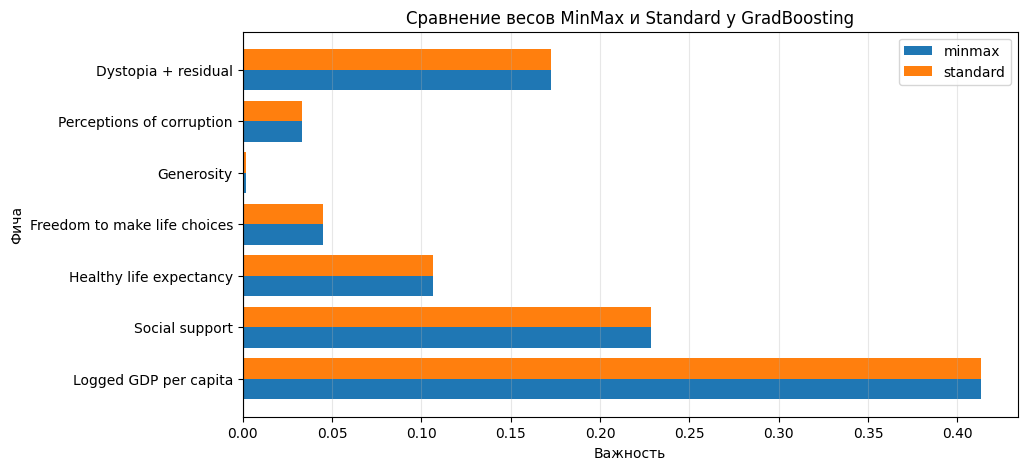

In [18]:
reg_grad_minmax_importantces = reg_grad_minmax.feature_importances_
reg_grad_standard_importantces = reg_grad_standard.feature_importances_

fig, ax = plt.subplots(figsize=(10,5))

ax.barh(y=feature_positions-0.2, width=reg_grad_minmax_importantces, height=0.4, label="minmax")
ax.barh(y=feature_positions+0.2, width=reg_grad_standard_importantces, height=0.4, label="standard")

ax.set_yticks(feature_positions)
ax.set_yticklabels(feature_names)
ax.grid(axis="x", alpha=0.3)
ax.axvline(x=0, color="black", alpha=0.5)
ax.set_title("Сравнение весов MinMax и Standard у GradBoosting")
ax.set_ylabel("Фича")
ax.set_xlabel("Важность")
ax.legend()

plt.show()

**Ваш вывод здесь:** Видно, что, во первых, метод масштабирования здесь ни на что не влияет, а, во вторых, Generosity бесполезен. То же самое, кстати, доказал и Lasso, так как вне зависимости от метода масштабирования, штраф за вес у него перевесил его пользу -> веса и там, и там, были 0

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:** 
Пусть исходный признак обозначен через $x_j$.

Для `MinMaxScaler`:
$$
z_j = \frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}}.
$$

Линейная модель, обученная на MinMax-признаках, имеет вид:
$$
f(x) = b_{mm} + \sum_{j=1}^{p} w^{mm}_j z_j
     = b_{mm} + \sum_{j=1}^{p} w^{mm}_j
       \frac{x_j - x_j^{\min}}{x_j^{\max} - x_j^{\min}}.
$$

Перепишем её в исходных единицах:
$$
f(x) =
\left(
b_{mm} - \sum_{j=1}^{p}
\frac{w^{mm}_j x_j^{\min}}{x_j^{\max} - x_j^{\min}}
\right)
+
\sum_{j=1}^{p}
\frac{w^{mm}_j}{x_j^{\max} - x_j^{\min}} x_j.
$$

Значит коэффициент при исходном признаке равен:
$$
a_j = \frac{w^{mm}_j}{x_j^{\max} - x_j^{\min}}.
$$

Для `StandardScaler`:
$$
s_j = \frac{x_j - \mu_j}{\sigma_j}.
$$

Модель на стандартизованных признаках:
$$
f(x) = b_{std} + \sum_{j=1}^{p} w^{std}_j s_j
     = b_{std} + \sum_{j=1}^{p} w^{std}_j
       \frac{x_j - \mu_j}{\sigma_j}.
$$

Коэффициент при исходном признаке здесь равен:
$$
a_j = \frac{w^{std}_j}{\sigma_j}.
$$

Так как обе модели описывают одну и ту же линейную зависимость, получаем:
$$
\frac{w^{std}_j}{\sigma_j}
=
\frac{w^{mm}_j}{x_j^{\max} - x_j^{\min}}.
$$

Отсюда переход от MinMax-коэффициентов к Standard-коэффициентам:
$$
w^{std}_j =
w^{mm}_j
\frac{\sigma_j}{x_j^{\max} - x_j^{\min}}.
$$

Свободный член:
$$
b_{std}
=
b_{mm}
-
\sum_{j=1}^{p}
\frac{w^{mm}_j x_j^{\min}}{x_j^{\max} - x_j^{\min}}
+
\sum_{j=1}^{p}
\frac{w^{mm}_j \mu_j}{x_j^{\max} - x_j^{\min}}.
$$

Итого: коэффициенты линейной модели зависят от выбранного масштаба признаков, поэтому напрямую сравнивать веса моделей, обученных после разных scaler'ов, некорректно. Их нужно сначала привести к одной шкале.

In [19]:
intercept_std = reg_lin_minmax.intercept_
coef_std = []

for i in range(reg_lin_minmax.n_features_in_):
    cur_minmax_weight = reg_lin_minmax_coefs[i]
    cur_max = sc_minmax.data_max_[i]
    cur_min = sc_minmax.data_min_[i]
    cur_mean = sc_standard.mean_[i]
    cur_std = sc_standard.scale_[i]

    intercept_std -= (cur_min * cur_minmax_weight) / (cur_max - cur_min)
    cur_base_coef = (cur_minmax_weight / (cur_max - cur_min))
    intercept_std += cur_base_coef * cur_mean
    cur_standard_coef = cur_base_coef * cur_std
    coef_std.append(cur_standard_coef)

assert round(intercept_std, 4) == round(reg_lin_standard.intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(reg_lin_standard.coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [20]:
lr_minmax =  reg_lin_minmax
gb_minmax =  reg_grad_minmax

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


In [21]:
print(feature_name, X[feature_name].min(), X[feature_name].max())

Social support 0.463 0.983


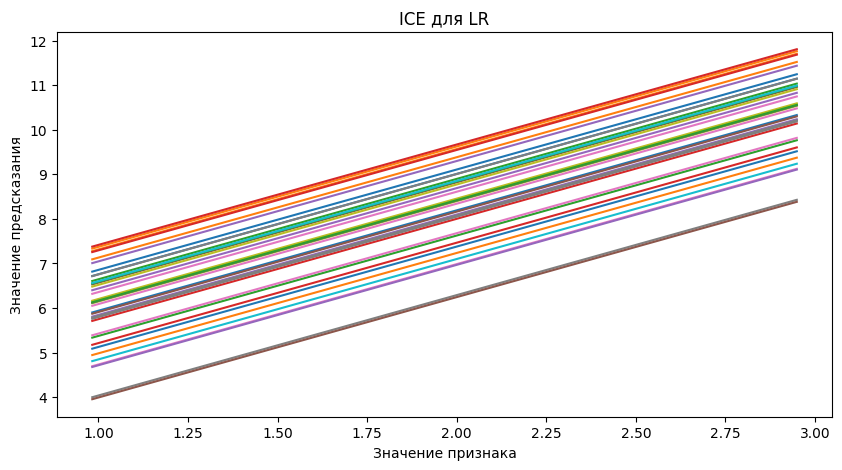

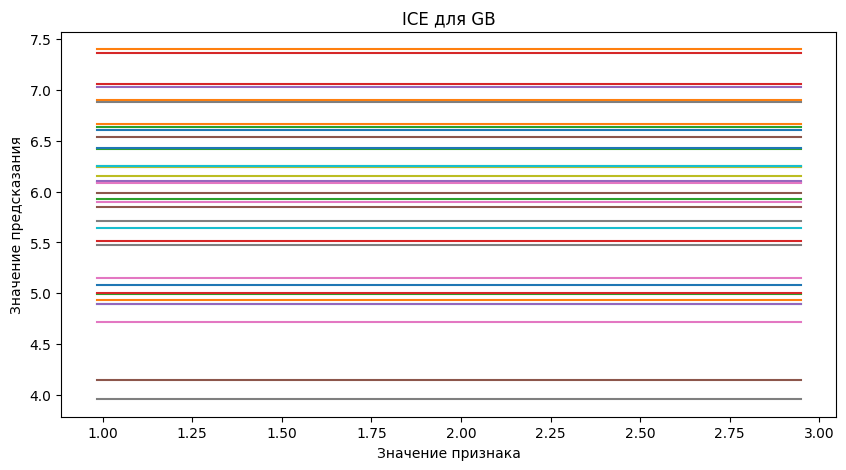

In [22]:
values = np.linspace(X[feature_name].max(), X[feature_name].max() * 3, num=20)
predictions_lr = np.zeros((X_test.shape[0], 20))
predictions_gb = np.zeros((X_test.shape[0], 20))
fig0, ax0 = plt.subplots(figsize=(10, 5))
fig1, ax1 = plt.subplots(figsize=(10, 5))

for i, value in enumerate(values):
    X_test_temp = X_test.copy()
    X_test_temp[feature_name] = value
    X_test_temp = sc_minmax.transform(X_test_temp)
    predicted_temp_lr = lr_minmax.predict(X_test_temp)
    predicted_temp_gb = gb_minmax.predict(X_test_temp)
    predictions_lr[:, i] = predicted_temp_lr
    predictions_gb[:, i] = predicted_temp_gb

for i in range(X_test.shape[0]):
    cur_object = predictions_lr[i]
    ax0.plot(values, cur_object)

for i in range(X_test.shape[0]):
    cur_object = predictions_gb[i]
    ax1.plot(values, cur_object)

ax0.set_xlabel("Значение признака")
ax0.set_ylabel("Значение предсказания")
ax0.set_title("ICE для LR")
ax1.set_xlabel("Значение признака")
ax1.set_ylabel("Значение предсказания")
ax1.set_title("ICE для GB")

plt.show()

**Ваш вывод здесь:** Как и по теории бустинг не может работать с сильными отклонениями от обучающего интервала. Все трешхолды были рассмотрены внутри трейна, следовательно ветвления остаются такими же и условный train_max попадет туда же, куда и train_max + e (e > 0), то есть между ними отличия не будет. Для линейной модели же наоборот, она может экстраполировать зависимость при выходе из диапазона

### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


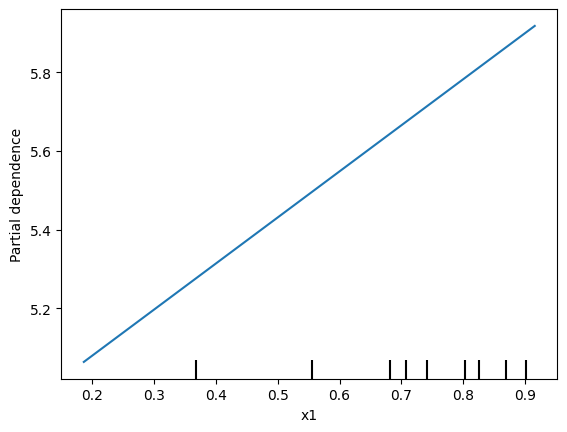

In [23]:
PartialDependenceDisplay.from_estimator(estimator=lr_minmax, X=X_test_sc_minmax, features=(feature_idx, ))
plt.show()

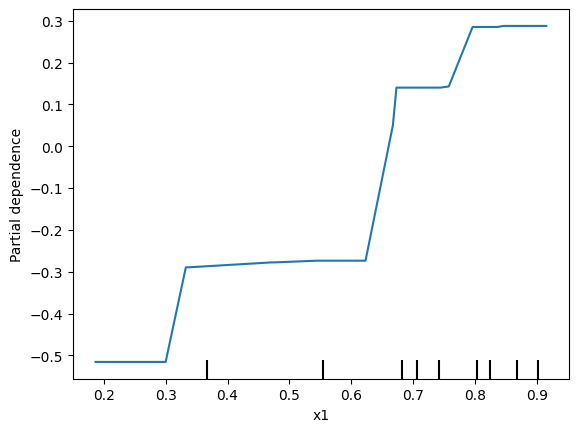

In [24]:
PartialDependenceDisplay.from_estimator(estimator=gb_minmax, X=X_test_sc_minmax, features=(feature_idx, ))
plt.show()

**Ваш вывод здесь:** PDP для LR показывает положительную линейную зависимость между фичей и таргетом. Поскольку модель линейная, эффект признака одинаковый на всем диапазоне. Для бустинга видны скачки, что тоже ожидаемо, ведь по сути это дерево, следовательно в узлах выборка делится на 2 части. Формулировка задания неточная - нужно ли делать pdp на множестве из задания 4 или нет, в итоге решил сделать встроенным методом из  sklearn передав внутрь модель.

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

In [25]:
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([("scaler", MinMaxScaler()), ("model", LinearRegression())])
pipe_gb = Pipeline([("scaler", MinMaxScaler()), ("model", GradientBoostingRegressor(max_depth=2, random_state=42))])

pipe_lr.fit(X=X_train, y=y_train)
pipe_gb.fit(X=X_train, y=y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a 

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


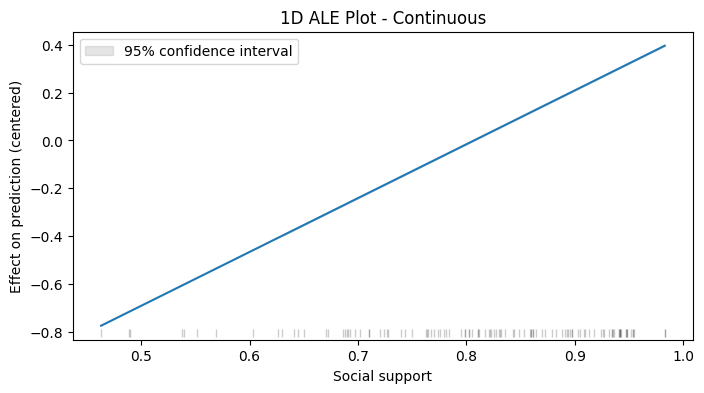

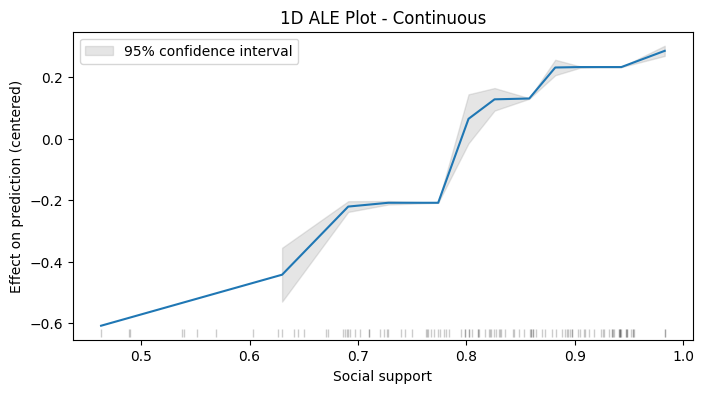

In [26]:
from PyALE import ale

ale_lr = ale(X=X_train, model=pipe_lr, feature=[feature_name], grid_size=12, include_CI=True)
ale_gb = ale(X=X_train, model=pipe_gb, feature=[feature_name], grid_size=12, include_CI=True)

**Ваши выводы здесь:** У линейной регрессии ale простая линия, что в целом ожидаемо. интервалов нету, так как в модели вклад признака постоянен и почти не зависит от остальных признаков. У бустинга все еще видно положительное влияние нашей фичи, тут доверительные интервалы показывают разброc. Это вытекает из того, что когда в узле по нашему признаку мы, скажем, пошли направо, у нас существуют следующие ветвления, вероятно по другим признакам, которые приводят к разным значениям таргета. выбрал grid size 12 так как он дает баланс между устойчивостью оценки и детализацией графика 

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

In [27]:
from sklearn.inspection import permutation_importance
for i in [1, 2, 3, 5, 10, 20, 30, 40, 50]:
    permutation_cur_lr = permutation_importance(estimator=pipe_lr, X=X_test, y=y_test, n_repeats=i, random_state=42)
    permutation_cur_gb = permutation_importance(estimator=pipe_gb, X=X_test, y=y_test, n_repeats=i, random_state=42)
    print(f"n_repeats={i}")
    print("LR", "\n", f"Mean importances: {permutation_cur_lr.importances_mean}", "\n", f"Std of importances: {permutation_cur_lr.importances_std}")
    print("GB", "\n", f"Mean importances: {permutation_cur_gb.importances_mean}", "\n", f"Std of importances: {permutation_cur_gb.importances_std}")
    print("\n\n")

n_repeats=1
LR 
 Mean importances: [0.25837182 0.13261936 0.1096742  0.03304626 0.0085832  0.01813673
 0.85215641] 
 Std of importances: [0. 0. 0. 0. 0. 0. 0.]
GB 
 Mean importances: [0.25993498 0.16556437 0.05236616 0.02929353 0.00268362 0.00659672
 0.54798025] 
 Std of importances: [0. 0. 0. 0. 0. 0. 0.]



n_repeats=2
LR 
 Mean importances: [0.28146511 0.10047999 0.11319655 0.02962117 0.00925735 0.02271913
 0.7402392 ] 
 Std of importances: [0.02309329 0.03213937 0.00352235 0.0034251  0.00067416 0.00458241
 0.11191721]
GB 
 Mean importances: [0.30613575 0.11900032 0.0495553  0.02568246 0.00226071 0.00285548
 0.47384245] 
 Std of importances: [0.04620077 0.04656405 0.00281087 0.00361108 0.00042291 0.00374124
 0.0741378 ]



n_repeats=3
LR 
 Mean importances: [0.26208755 0.09525689 0.10315312 0.02713289 0.00979864 0.02375477
 0.72930492] 
 Std of importances: [0.03326429 0.02726147 0.01449179 0.00449488 0.00094285 0.00401797
 0.09267915]
GB 
 Mean importances: [ 2.88530563e-01  1.0850

**Ваши выводы здесь:** При малом количестве перестановок важности шумят, в особенности на Gb, для линейной регрессии в меньшей степени. При n_repeats=20 важности уже в целом стабилизируются. А стандартное отклонение с ростом количества перестановок растет. Также имеет место быть пропорциональность между важностью признака и стандартного отклонения. По полученным данным самым важным признаком является последний, на нем отклонение больше всего. Самый бесполезный - 5

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



In [28]:
def occlusion_importance(estimator, X, y, beta):
    features_medians = X.median()
    importances = []
    for i, feature_median in enumerate(features_medians):
        X_cur = X.copy()
        X_cur.iloc[:, i] = X_cur.iloc[:, i] * (1 - beta) + beta * feature_median
        importances.append(mean_squared_error(y, estimator.predict(X_cur)) - mean_squared_error(y, estimator.predict(X)))
    return importances
    

beta = 0.2
GB
[0.014085419944500265, 0.004355901628179418, 0.0024543845563778444, 0.0024906523196619075, 0.0005896194116419779, 0.0014346814290786616, 0.010712003075575321]



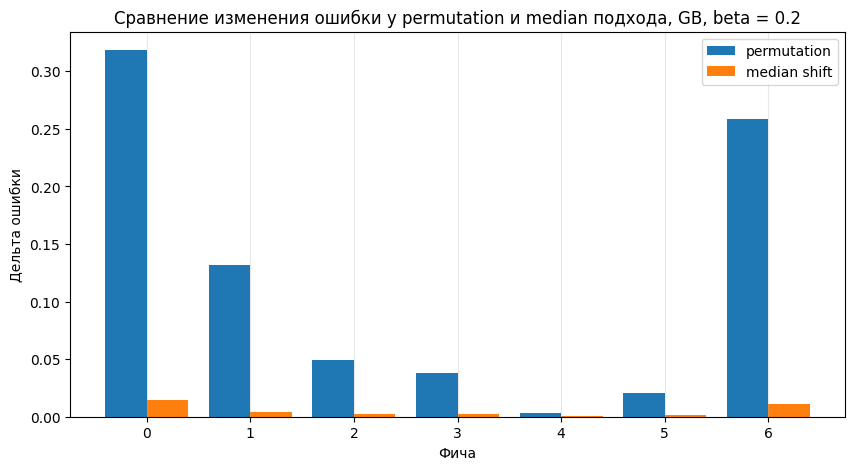

beta = 0.5
GB
[0.1149888679659686, 0.017186506238449542, 0.01249384122280112, 0.011838276144784655, 0.001594494273098379, 0.007858093050966162, 0.040624310643217545]



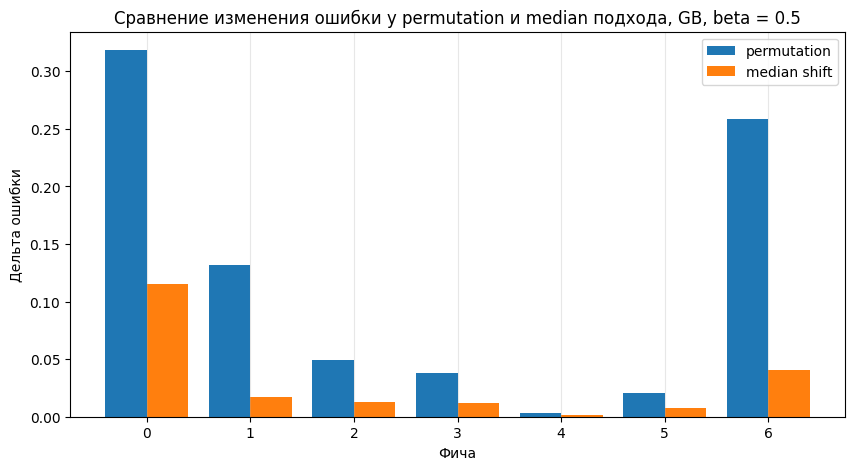

beta = 1
GB
[0.21438733527181542, 0.11010446289254866, 0.04903705047134183, 0.029009002811478026, 0.00243084095295615, 0.024106754944239844, 0.18213461420094088]



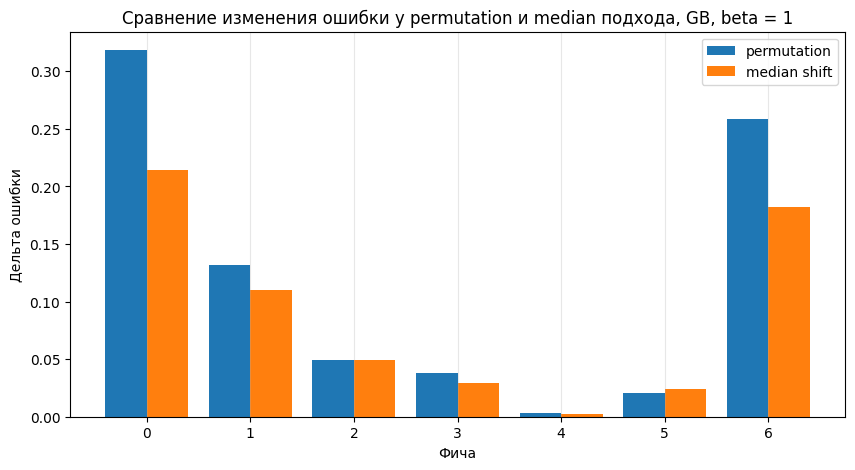

In [29]:
x = np.arange(reg_lin_minmax.n_features_in_)
permutation_gb = permutation_importance(estimator=pipe_gb, X=X_train, y=y_train, n_repeats=30, random_state=42)

for beta in [0.2, 0.5, 1]:
    importances_gb = occlusion_importance(pipe_gb, X_train, y_train, beta)
    print(f"beta = {beta}")
    print(f"GB\n{importances_gb}\n")

    fig, ax = plt.subplots(figsize=(10,5))

    ax.bar(x=x-0.2, height=permutation_gb.importances_mean, width=0.4, label="permutation")
    ax.bar(x=x+0.2, height=importances_gb, width=0.4, label="median shift")

    ax.grid(axis="x", alpha=0.3)
    ax.set_title(f"Сравнение изменения ошибки у permutation и median подхода, GB, beta = {beta}")
    ax.set_ylabel("Дельта ошибки")
    ax.set_xlabel("Фича")
    ax.legend()

    plt.show()


**Ваши выводы здесь:** Важности, очевидно, растут с ростом беты так как мы сильнее прижимаем признаки к медиане, то есть нивелируем их эффект. Теперь по непосредственно результатам - результаты похожи на задание 7. Наиболее важными оказались ввп, social support и dystopia + residual. Их сдвиг к медиане сильно увеличивает MSE -> там заложена ценная информация. Generosity по классике оказался практически бесполезным и при beta=1 его сдвиг к  медиане увеличивает MSE на 0.0024 (для ввп, например, 0.214). Относительно permutation при beta=1 результаты пропорциональны, но в абсолютных величинах меньше

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

In [30]:
import shap

shap.initjs()

explainer_lr = shap.Explainer(lr_minmax, shap.maskers.Independent(data=X_train_sc_minmax))
explainer_gb = shap.Explainer(gb_minmax, X_train_sc_minmax)

shap_values_lr = explainer_lr(X_test_sc_minmax)
shap_values_gb = explainer_gb(X_test_sc_minmax)

shap.plots.force(shap_values_lr)

/home/maxak/.pyenv/versions/3.14.2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


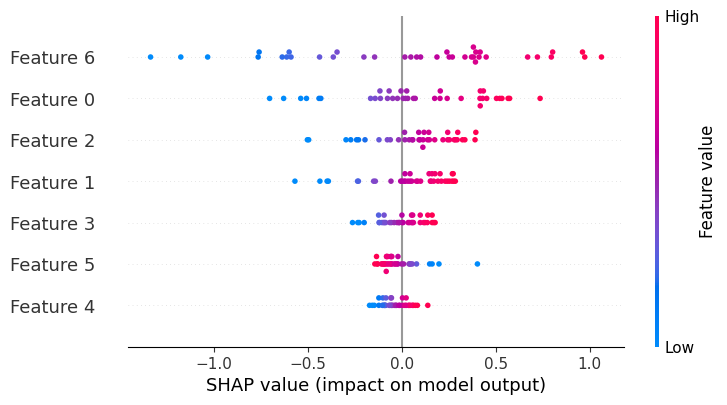

In [31]:
shap.plots.beeswarm(shap_values_lr)

In [32]:
shap.plots.force(shap_values_gb)

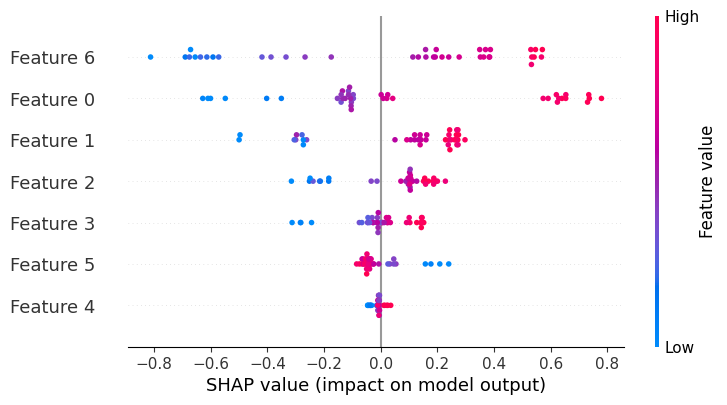

In [33]:
shap.plots.beeswarm(shap_values_gb)

 **Ваш вывод здесь:** Снова самыми важными (в обоих моделях) оказались ввп (0), Dystopia + residual (6, его важность вытекает из того, что он является частью формулы Ladder Score), а также Social Support (1) и Healthy life expectancy (2). Остальные признаки не так важны и значение SHAP не сильно меняется при их отсутствии. По читаемости - beeswarm, пожалуй, самый оптимальный, force нечитаем.

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

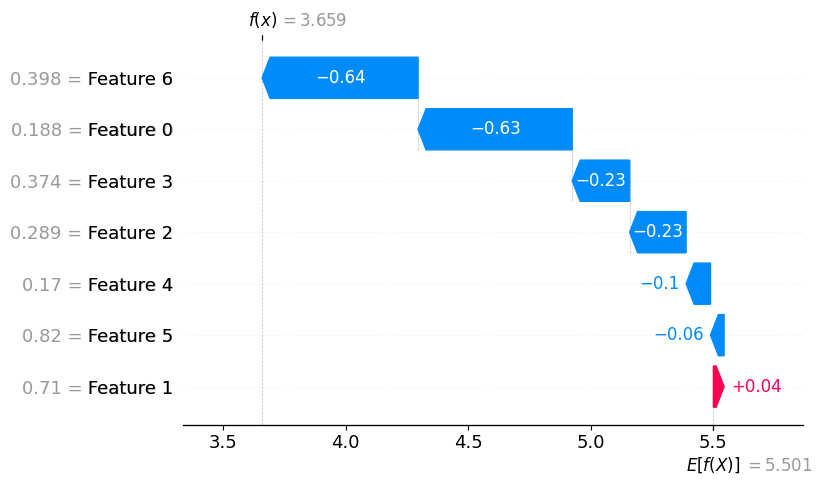

In [34]:
shap.plots.waterfall(shap_values_lr[7])

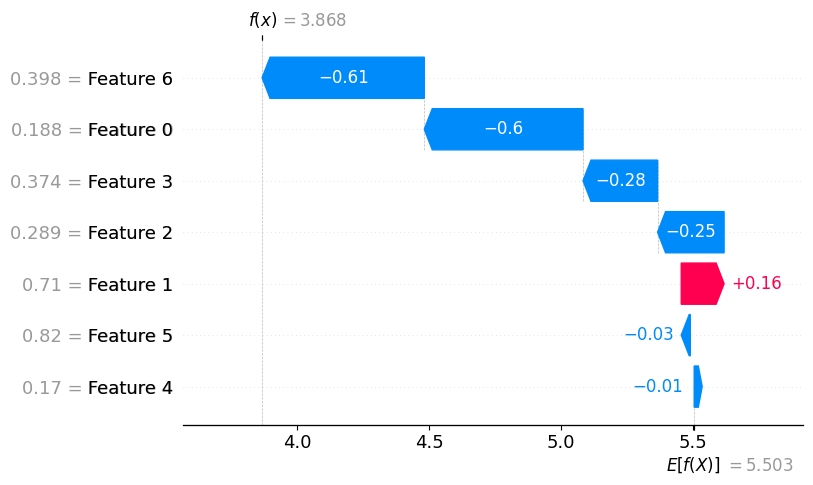

In [35]:
shap.plots.waterfall(shap_values_gb[7])

**Ваш вывод здесь:** Для объекта 7, например, 3 фича (свобода делать какие то выборы) оказалась важнее продолжительности жизни. Коррупция и щедрость как не влияли, так и не влияют. Также интересно то, что Social support который всегда давал неплохой вклад, на 7 объекте в случае линрега наоборот самый бесполезный, даже хуже 4 и 5. В бустинге же он на 3 месте. В общем в зависимости от объекта важность признака может сильно разниться -> для анализа нужно иметь хотя бы какую то выборку, повторяющую распределение изначальной

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

In [36]:
from lime.lime_tabular import LimeTabularExplainer

lime_exp_lr = LimeTabularExplainer(training_data=X_train_sc_minmax, mode="regression", feature_names=feature_names, kernel_width=np.sqrt(len(feature_names)) * 0.75)
lime_exp_gb = LimeTabularExplainer(training_data=X_train_sc_minmax, mode="regression", feature_names=feature_names, kernel_width=np.sqrt(len(feature_names)) * 0.75)
exp_lr = lime_exp_lr.explain_instance(data_row=X_test_sc_minmax[7], predict_fn=lr_minmax.predict)
exp_gb = lime_exp_gb.explain_instance(data_row=X_test_sc_minmax[7], predict_fn=gb_minmax.predict)

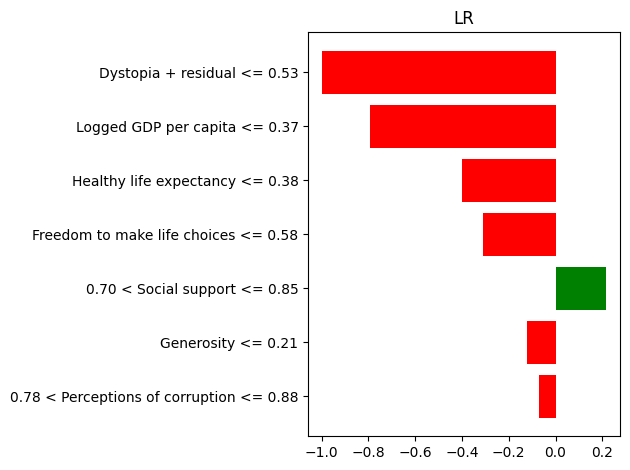

In [37]:
fig_lr = exp_lr.as_pyplot_figure()
fig_lr.tight_layout()
plt.title("LR")
plt.show()

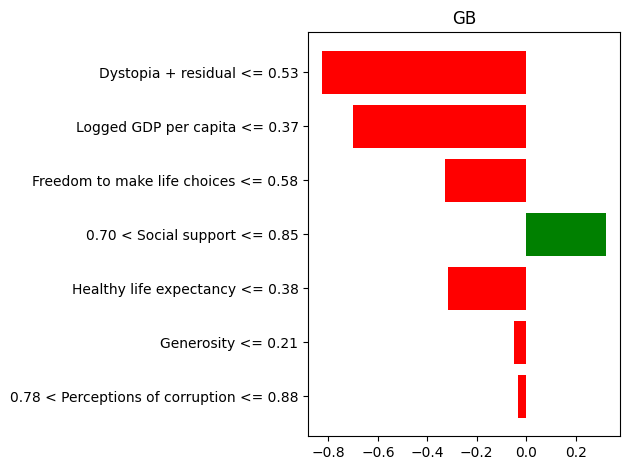

In [38]:
fig_gb = exp_gb.as_pyplot_figure()
fig_gb.tight_layout()
plt.title("GB")
plt.show()

Для выбранного объекта картина похожая. Все признаки кроме Social support тянут предсказания вниз. В остальном GB и LR похожи, но отрицательные вклады у LR все таки больше. А так результаты похожи на shap, основные признаки остались теми же, но в линреге generosity победил social support.

### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [39]:
def lime(x0, kernel_width, model=gb_minmax, epsilon=0.1, n=5000):
    x0 = np.asarray(x0)
    noise = np.random.normal(scale=epsilon, size=(n, x0.size))
    points = noise + x0
    predictions = model.predict(points)
    distances = np.sqrt(np.sum((points-x0)**2, axis=1))
    weigths = np.exp(-distances**2 / kernel_width**2)
    temp_reg = LinearRegression()
    temp_reg.fit(X=points, y=predictions, sample_weight=weigths)
    return temp_reg.coef_

In [40]:
temp = np.sqrt(len(feature_names))

for n in [100, 250, 500, 1000, 2500, 5000, 10000]:
    for multiplier in [0.1, 0.25, 0.5, 0.75, 1]:
        print(f"n = {n}\nkernel multiplier = {multiplier}")
        for iter in range(5):
            print(lime(x0=X_test_sc_minmax[7], kernel_width=temp*multiplier, n=n))

n = 100
kernel multiplier = 0.1
[ 1.59788087  1.69170675  0.24538481  0.72110357  0.53505786 -0.23907884
  1.62059115]
[ 0.97112161  1.58804935  0.35161816  0.21559025 -0.20571261 -0.2851627
  1.84060047]
[ 1.24109387  2.13964114  0.30168272  0.4702044   0.04347524 -0.40932661
  1.06335632]
[1.19028909 2.21550482 0.39864861 0.68953791 0.08994536 0.20851513
 1.56441492]
[ 1.28954562  2.20965644  0.13159655  0.88956329  0.24328545 -0.11514023
  1.6480574 ]
n = 100
kernel multiplier = 0.25
[ 1.4197274   2.36638641  0.22269761  0.42106152 -0.00314518 -0.38875161
  2.1281162 ]
[ 1.47220516  1.91345464  0.19341286  0.73363486 -0.03108643  0.14228414
  1.82511117]
[ 1.80244619  1.8665539   0.27619784  0.59534492  0.08209601 -0.26699838
  1.75960736]
[1.63961154 2.0400958  0.16511114 0.66733772 0.29039882 0.13252392
 1.79931841]
[ 1.30683232  2.13790789  0.42675363  0.57692893  0.23024518 -0.00867621
  1.69112768]
n = 100
kernel multiplier = 0.5
[ 1.4865494   1.83220455  0.1590329   0.60532594

 **Ваш вывод здесь:** Функция довольно устойчивая, ширина ядра практически не влияет на веса, а начиная с 2500 точек в окрестности веса в целом окончательно стабилизируются и показывают истинную картину. А так в общем и целом ничего не поменялось, generosity слаб как и коррупция, остальные признаки важны сильнее. Вообще тут на порядок и результаты помимо n влияет сильно epsilon, при eps=0.01, например, коррупция стала резко важной, а при увеличении до 0.1 social support резко вырос так как окрестность шире и модель видит реальные локальные переходы бустинга

## **Вы проделали огромную работу! Ура!**